In [1]:
import os
import subprocess
import logging
import sys

def source_lmod_script(script_path):
    """
    Source an Lmod/module script and import environment variables into Python safely,
    suppressing terminal warnings.
    """
    # Use a non-interactive login shell (bash -l), redirect errors
    command = f'bash -l -c "source {script_path} >/dev/null 2>&1; printenv -0"'
    
    proc = subprocess.Popen(command, stdout=subprocess.PIPE, shell=True)
    out, _ = proc.communicate()
    
    # Parse null-separated environment variables
    for env_var in out.split(b'\0'):
        if env_var:
            key, _, value = env_var.partition(b'=')
            os.environ[key.decode()] = value.decode()

# Example usage
M3_BUILD_DIR = "/home/henryi/scratch/venvs/.venv_sbi/bin/"
TUTORIAL_BUILD_DIR = M3_BUILD_DIR
source_lmod_script(f"{M3_BUILD_DIR}/setup.MaCh3.sh")
source_lmod_script(f"{TUTORIAL_BUILD_DIR}/setup.MaCh3Tutorial.sh")
os.environ["OMP_NUM_THREADS"] = "8"


my_stderr = sys.stderr = open('errors.txt', 'w')  # redirect stderr to file
get_ipython().log.handlers[0].stream = my_stderr  # log errors to new stderr
get_ipython().log.setLevel(logging.INFO)  # errors are logged at info level

cat: write error: Broken pipe
cat: write error: Broken pipe
Warning in <TROOT::Append>: Replacing existing TH1: hRecoNeutrinoEnergyTutorial (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hRecoNeutrinoEnergyTutorial (Potential memory leak).


In [2]:
from mach3sbitools.inference.sbi_interface import MaCh3SBIInterface
from mach3sbitools.utils.logger import MaCh3Logger, get_logger
from mach3sbitools.utils.config import PosteriorConfig

import pickle as pkl
from pathlib import Path

import uproot as ur

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

from tqdm import tqdm
import numpy as np
from scipy.stats import gaussian_kde
from tqdm import tqdm

from rich.table import Table
from rich.console import Console

import torch

logger = get_logger("mach3sbitools")
log_level='INFO'
log_file=None
MaCh3Logger("mach3sbitools", level=log_level, log_file=log_file)

In [3]:
# Plotting utils
def circular_credible_interval(sample, lo_p, hi_p, period=2 * np.pi):
    sample = np.sort(sample % period)
    n = len(sample)
    n_in = int(np.ceil((hi_p - lo_p) / 100 * n))
    sample_ext = np.concatenate([sample, sample + period])
    idx = np.argmin(sample_ext[n_in : n_in + n] - sample_ext[:n])
    lo = (sample_ext[idx] % period + np.pi) % period - np.pi
    hi = (sample_ext[idx + n_in] % period + np.pi) % period - np.pi
    return lo, hi


def get_credible_intervals(sample, is_circular=False):
    return {
        label: circular_credible_interval(sample, lo_p, hi_p)
        if is_circular
        else tuple(np.percentile(sample, [lo_p, hi_p]))
        for label, (lo_p, hi_p) in CI_LEVELS.items()
    }


def get_best_fit(sample, is_circular=False):
    """Posterior mean — minimum MSE point estimate."""
    if is_circular:
        return np.arctan2(np.mean(np.sin(sample)), np.mean(np.cos(sample)))
    return np.mean(sample)


def plot_credible_intervals(ax, bounds, color):
    for label, (lo, hi) in bounds.items():
        ax.axvline(lo, color=color, linestyle=CI_STYLES[label], alpha=0.7)
        ax.axvline(hi, color=color, linestyle=CI_STYLES[label], alpha=0.7)


def plot_best_fit(ax, best_fit, color, ypos=0.92):
    """Draw the best-fit as a vertical line with an 'x' marker near the top."""
    ymin, ymax = ax.get_ylim()
    ax.axvline(best_fit, color=color, linestyle="solid", linewidth=1.5, alpha=0.9)
    ax.plot(best_fit, ymin + ypos * (ymax - ymin),
            marker="x", markersize=8, markeredgewidth=2,
            color=color, zorder=5, clip_on=False)


def wrap_circular(arr):
    return (arr + np.pi) % (2 * np.pi) - np.pi



In [15]:
inference = MaCh3SBIInterface("Tutorial", Path("/home/henryi/sft/MaCh3Tutorial/TutorialConfigs/FitterConfig.yaml"),
                              cyclical_pars=['delta_cp'])


[Manager.cpp][info] Setting config to be: /home/henryi/sft/MaCh3Tutorial/TutorialConfigs/FitterConfig.yaml
[Manager.cpp][info] Config is now: 
[Monitor.cpp][info] General:
[Monitor.cpp][info]   OutputFile: Test_50m.root
[Monitor.cpp][info]   TutorialSamples: [/home/henryi/sft/MaCh3Tutorial/TutorialConfigs/Samples/SampleHandler_Tutorial.yaml]
[Monitor.cpp][info]   FittingAlgorithm: MR2T2
[Monitor.cpp][info]   RealData: false
[Monitor.cpp][info]   Asimov: true
[Monitor.cpp][info]   CustomReWeight: false
[Monitor.cpp][info]   FakeData: false
[Monitor.cpp][info]   ProcessMCMC: No
[Monitor.cpp][info]   Debug: No
[Monitor.cpp][info]   RandomStart: false
[Monitor.cpp][info]   Seed: 0
[Monitor.cpp][info]   MaCh3Modes: TutorialConfigs/MaCh3Modes.yaml
[Monitor.cpp][info]   Fitter:
[Monitor.cpp][info]     FitTestLikelihood: false
[Monitor.cpp][info]   Minuit2:
[Monitor.cpp][info]     NSteps: 100000
[Monitor.cpp][info]   PSO:
[Monitor.cpp][info]     Constriction: 1
[Monitor.cpp][info]     Inertia:

In [19]:
model_path = Path(f"/home/henryi/scratch/TutorialSBI/analyses/10M_256Hid_15Tr_MAF_lr1e-4/models/256hid_20tr.ts")

xo = inference.simulator.mach3_wrapper.get_data_bins()

posterior_config = PosteriorConfig(
    hidden_features = 256,      # was 50 — scale up to match data volume
    num_transforms= 20,         # was 10 — fewer needed with NSF, less sequential overhead
    dropout_probability= 0.1,  # fine as-is, good regularisation for 5M samples  
    num_blocks= 2,             # fine as-is
    # NSF-specific
    # num_bins= 10,             
    # spline bins, 8-12 is the usual sweet spot
)

inference.load_posterior(model_path, posterior_config)
samples = inference.sample_posterior(5000000, x=xo).cpu()

2026-03-03 11:59:49 INFO     Loading autosave checkpoint from epoch 5873

                    INFO     NPE created | maf | hidden=256 transforms=20 blocks=2 bins=10

                    INFO     Density estimator loaded from                                                         
                             /home/henryi/scratch/TutorialSBI/analyses/10M_256Hid_15Tr_MAF_lr1e-4/models/256hid_20t
                             r.ts

                    INFO     Sampling 5,000,000 points from posterior

  0%|          | 0/5000000 [00:00<?, ?it/s]

In [11]:
# input_tree = "/home/henryi/sft/MaCh3Tutorial/Test_AsimovB.root"
# mach3_chain = ur.open(f"{input_tree}:posteriors").arrays(library="np")

input_tree = "/home/henryi/sft/MaCh3Tutorial/Test_NoAdapt.root"
mach3_chain = ur.open(f"{input_tree}:posteriors").arrays(library="np")


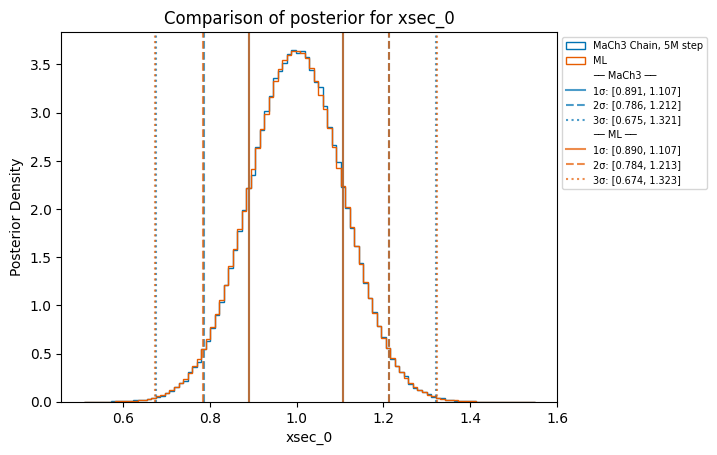

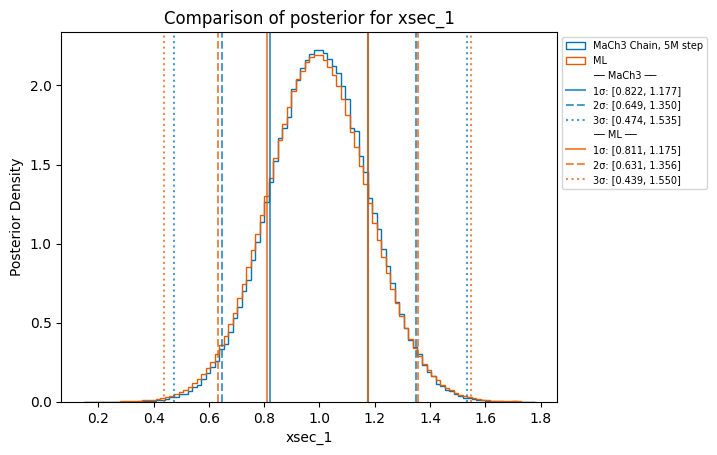

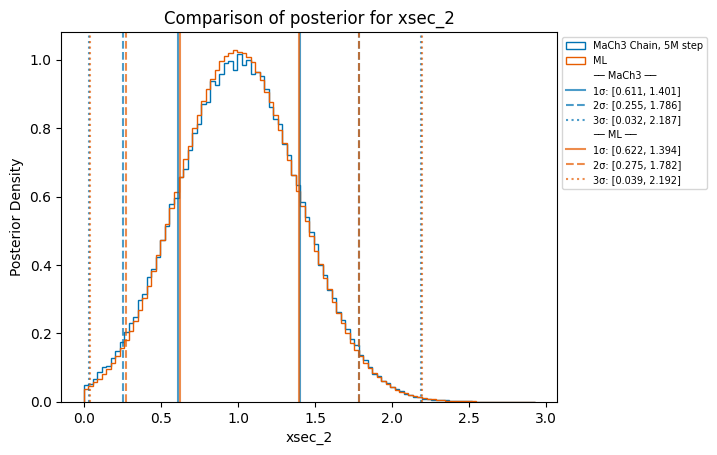

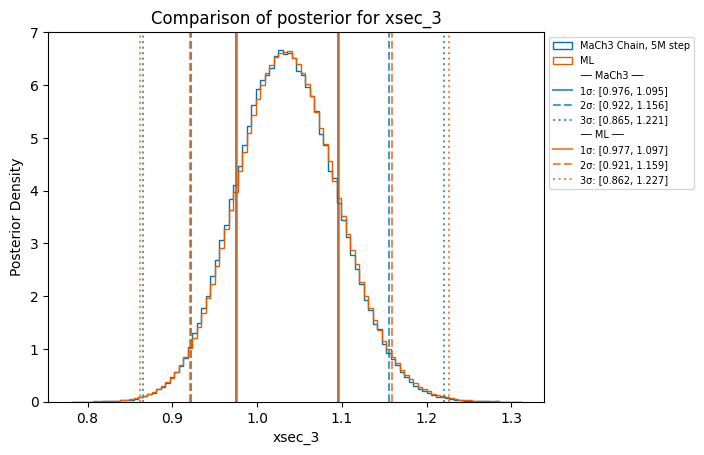

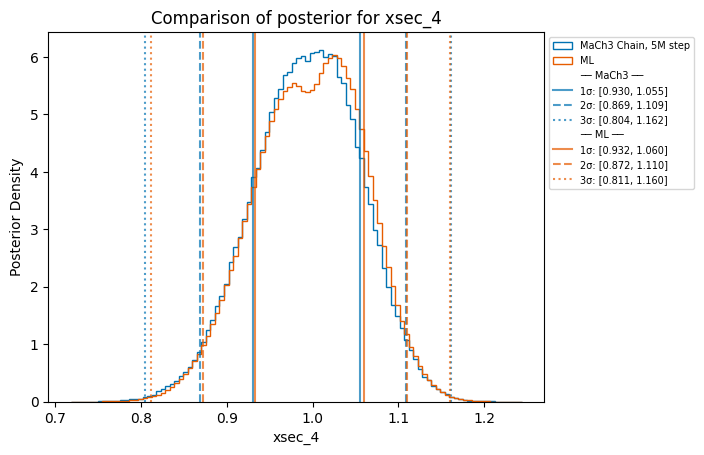

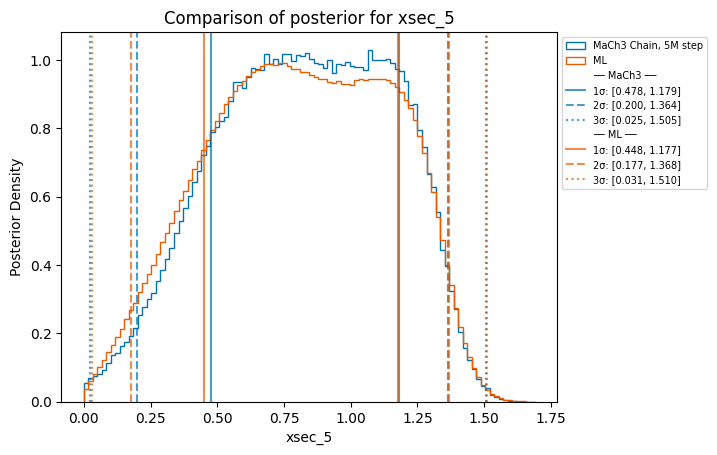

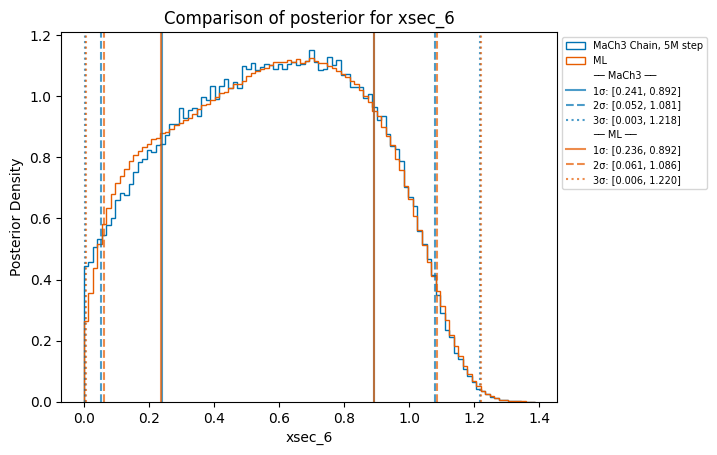

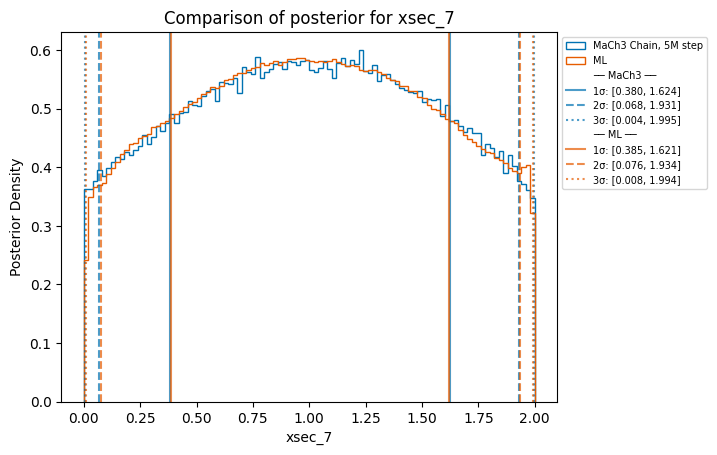

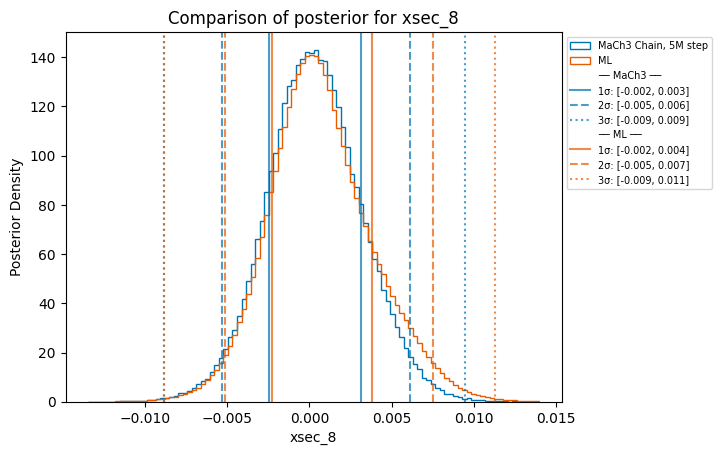

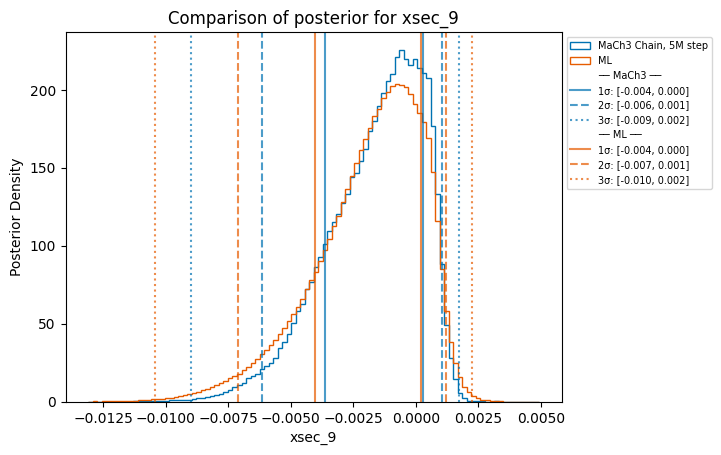

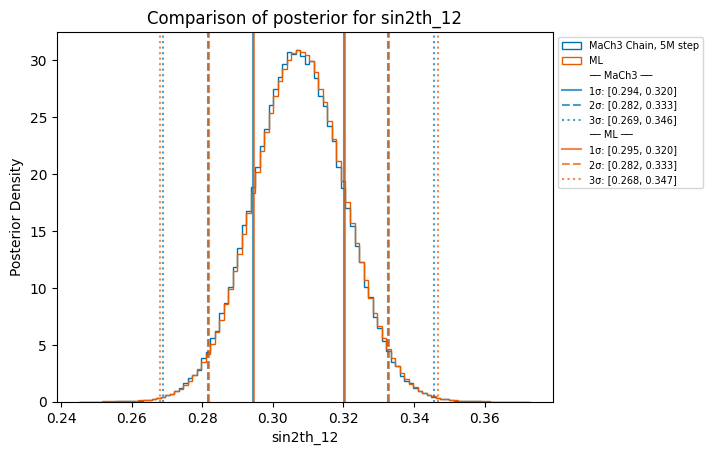

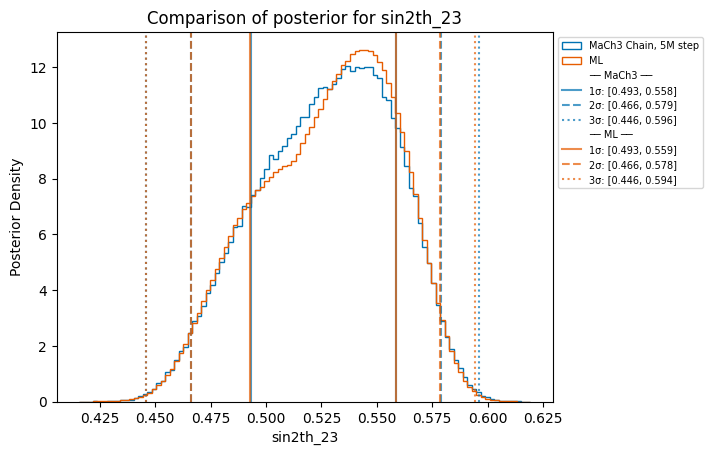

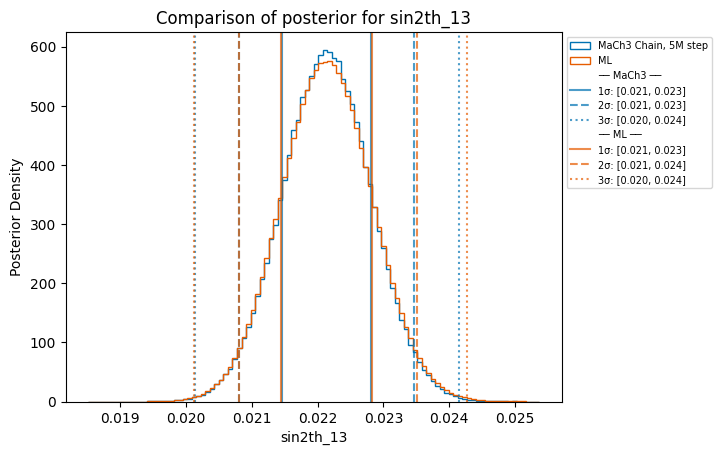

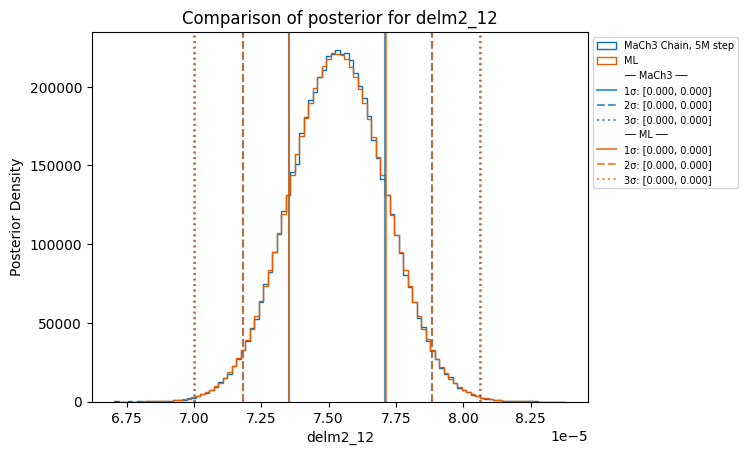

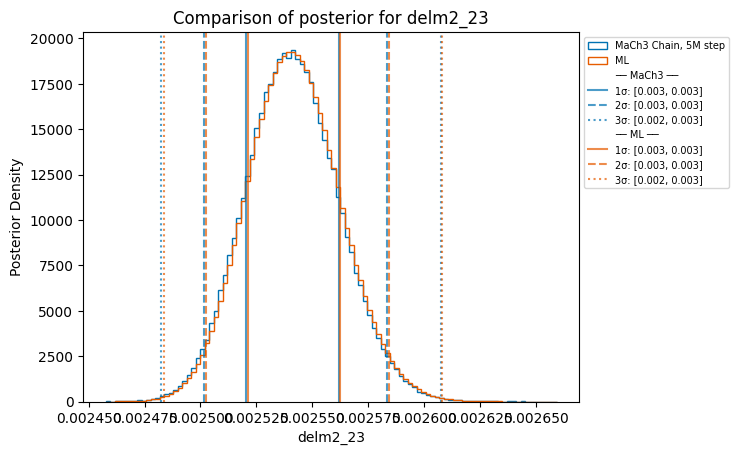

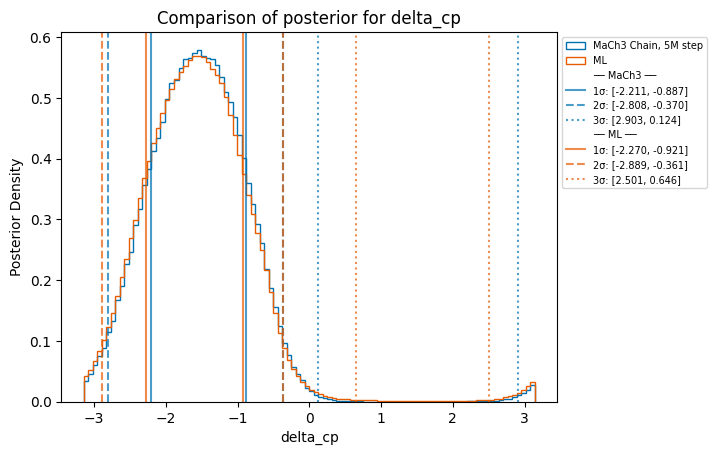

                                 Posterior Credible Intervals                                 
┏━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Parameter ┃ Model ┃ Best Fit ┃    1σ [16, 84]     ┃   2σ [2.5, 97.5]   ┃ 3σ [0.15, 99.85]  ┃
┡━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ xsec_0    │ MaCh3 │  0.9990  │  [0.8905, 1.1072]  │  [0.7857, 1.2122]  │ [0.6751, 1.3207]  │
│           │ ML    │  0.9985  │  [0.8897, 1.1073]  │  [0.7841, 1.2128]  │ [0.6742, 1.3233]  │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ xsec_1    │ MaCh3 │  0.9996  │  [0.8223, 1.1773]  │  [0.6490, 1.3497]  │ [0.4737, 1.5347]  │
│           │ ML    │  0.9930  │  [0.8113, 1.1749]  │  [0.6311, 1.3558]  │ [0.4386, 1.5498]  │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ xsec_2    │ MaCh3 │  1.0081  │  [0.6111, 1.4007]  │  [0.2547, 1.7863]  │ [0.0316, 2.1867]  │
│           │ ML    │  1.0091  │  [0.6217, 1.3937]  │  [0.2750, 1.7818]  │ [0.0387, 2.1917]  │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ xsec_3    │ MaCh3 │  1.0353  │  [0.9756, 1.0950]  │  [0.9215, 1.1560]  │ [0.8652, 1.2207]  │
│           │ ML    │  1.0368  │  [0.9769, 1.0968]  │  [0.9210, 1.1593]  │ [0.8622, 1.2270]  │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ xsec_4    │ MaCh3 │  0.9931  │  [0.9303, 1.0553]  │  [0.8686, 1.1091]  │ [0.8044, 1.1618]  │
│           │ ML    │  0.9967  │  [0.9324, 1.0599]  │  [0.8721, 1.1104]  │ [0.8115, 1.1602]  │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ xsec_5    │ MaCh3 │  0.8262  │  [0.4780, 1.1792]  │  [0.2002, 1.3636]  │ [0.0247, 1.5051]  │
│           │ ML    │  0.8095  │  [0.4485, 1.1767]  │  [0.1770, 1.3677]  │ [0.0312, 1.5098]  │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ xsec_6    │ MaCh3 │  0.5719  │  [0.2411, 0.8922]  │  [0.0518, 1.0805]  │ [0.0034, 1.2177]  │
│           │ ML    │  0.5715  │  [0.2361, 0.8921]  │  [0.0610, 1.0856]  │ [0.0063, 1.2205]  │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ xsec_7    │ MaCh3 │  1.0032  │  [0.3804, 1.6235]  │  [0.0676, 1.9309]  │ [0.0041, 1.9953]  │
│           │ ML    │  1.0033  │  [0.3849, 1.6210]  │  [0.0758, 1.9337]  │ [0.0080, 1.9939]  │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ xsec_8    │ MaCh3 │  0.0003  │ [-0.0025, 0.0031]  │ [-0.0053, 0.0061]  │ [-0.0088, 0.0095] │
│           │ ML    │  0.0007  │ [-0.0023, 0.0038]  │ [-0.0051, 0.0075]  │ [-0.0088, 0.0113] │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ xsec_9    │ MaCh3 │ -0.0017  │ [-0.0036, 0.0003]  │ [-0.0061, 0.0011]  │ [-0.0090, 0.0017] │
│           │ ML    │ -0.0019  │ [-0.0040, 0.0002]  │ [-0.0071, 0.0012]  │ [-0.0104, 0.0023] │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ sin2th_12 │ MaCh3 │  0.3072  │  [0.2943, 0.3201]  │  [0.2817, 0.3327]  │ [0.2690, 0.3458]  │
│           │ ML    │  0.3075  │  [0.2946, 0.3204]  │  [0.2818, 0.3330]  │ [0.2680, 0.3467]  │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ sin2th_23 │ MaCh3 │  0.5267  │  [0.4934, 0.5585]  │  [0.4661, 0.5789]  │ [0.4458, 0.5961]  │
│           │ ML    │  0.5273  │  [0.4930, 0.5589]  │  [0.4663, 0.5783]  │ [0.4457, 0.5944]  │
├───────────┼───────┼──────────┼────────────────────┼────────────────────┼───────────────────┤
│ sin2th_13 │ MaCh3 │  0.0221  │  [0.0215, 0.0228]  │  [0.0208, 0.0235]  │ [0.0201, 0.0242]  │
│           │ ML    │  0.0221  │  [0.0215, 0.0228]  │  [0.0208, 0.0235]  │ [0.0201, 0.0243]  │
├─────────

In [20]:
MACH3_LABEL = "MaCh3"
MACH3_COLOR = "#0072B2"

# Add as many ML entries as you like: label -> (samples_array, color)
ML_ENTRIES = {
    "ML":         (samples,         "#E65C00"),
}

CI_LEVELS = {"1σ": (16, 84), "2σ": (2.5, 97.5), "3σ": (0.15, 99.85)}#, "4σ": (100-99.9937, 99.9937)}
CI_STYLES = {"1σ": "solid", "2σ": "dashed", "3σ": "dotted"}#, "4σ": "dashdot"}

param_names = inference.simulator.mach3_wrapper.get_parameter_names()
summary    = {}   # name -> {model: bounds}
summary_bf = {}   # name -> {model: best_fit}

with PdfPages(model_path.parent.parent / "model_comp_ref.pdf") as pdf:
    for i, name in tqdm(enumerate(param_names), total=len(param_names)):
        is_circular = name == "delta_cp"

        # Build data dict: MaCh3 first, then all ML entries
        data = {MACH3_LABEL: (mach3_chain[name][10000:], MACH3_COLOR)}
        for label, (arr, color) in ML_ENTRIES.items():
            data[label] = (arr[:, i].cpu().numpy(), color)

        if is_circular:
            data = {k: (wrap_circular(arr), color) for k, (arr, color) in data.items()}

        bounds    = {k: get_credible_intervals(arr, is_circular) for k, (arr, _) in data.items()}
        best_fits = {k: get_best_fit(arr, is_circular)           for k, (arr, _) in data.items()}

        summary[name]    = bounds
        summary_bf[name] = best_fits

        fig, ax = plt.subplots()

        # MaCh3 sets the bins; ML entries reuse them
        _, bins, _ = ax.hist(
            data[MACH3_LABEL][0], bins=100, density=True, histtype="step",
            color=MACH3_COLOR, label=f"{MACH3_LABEL} Chain, 5M step"
        )
        for label, (arr, color) in data.items():
            if label == MACH3_LABEL:
                continue
            ax.hist(arr, bins=bins, density=True, histtype="step", color=color, label=label)

        for label, (_, color) in data.items():
            plot_credible_intervals(ax, bounds[label], color)

        # Draw best-fit crosses after histograms so y-limits are established
        fig.canvas.draw()
        # for label, (_, color) in data.items():
        #     plot_best_fit(ax, best_fits[label], color)

        # Legend: histogram entries + per-model CI + best-fit blocks
        hist_handles, _ = ax.get_legend_handles_labels()
        ci_handles = []
        for label, (_, color) in data.items():
            ci_handles.append(Line2D([], [], color="none", label=f"── {label} ──"))
            # ci_handles.append(
            #     Line2D([], [], color=color, linestyle="solid", linewidth=1.5,
            #            marker="x", markersize=6, markeredgewidth=1.5, alpha=0.9,
            #            label=f"Best fit: {best_fits[label]:.4f}")
            # )
            ci_handles += [
                Line2D([], [], color=color, linestyle=CI_STYLES[lbl], alpha=0.7,
                       label=f"{lbl}: [{lo:.3f}, {hi:.3f}]")
                for lbl, (lo, hi) in bounds[label].items()
            ]

        ax.legend(handles=hist_handles + ci_handles, loc="upper left",
                  bbox_to_anchor=(1, 1), fontsize=7)
        ax.set(xlabel=name, ylabel="Posterior Density",
               title=f"Comparison of posterior for {name}")

        pdf.savefig(fig, bbox_inches="tight")
        plt.show()
        plt.close(fig)

# Summary table
console = Console()
table = Table(title="Posterior Credible Intervals", show_header=True, header_style="bold")
for col, kw in [
    ("Parameter",         {"style": "cyan", "no_wrap": True}),
    ("Model",             {"style": "magenta"}),
    ("Best Fit",          {"justify": "center"}),
    ("1σ [16, 84]",       {"justify": "center"}),
    ("2σ [2.5, 97.5]",    {"justify": "center"}),
    ("3σ [0.15, 99.85]",  {"justify": "center"}),
]:
    table.add_column(col, **kw)

for name, bounds in summary.items():
    for j, (model, model_bounds) in enumerate(bounds.items()):
        table.add_row(
            name if j == 0 else "",
            model,
            f"{summary_bf[name][model]:.4f}",
            *[f"[{lo:.4f}, {hi:.4f}]" for lo, hi in model_bounds.values()],
        )
    table.add_section()

console.print(table)